# Cable Pose Estimation using GelSight Tactile Sensor

This notebook demonstrates cable pose estimation based on the paper:
**"Cable Manipulation with a Tactile-Reactive Gripper"** (Kaess et al., 2019)

## Overview
We will:
1. Load a GelSight tactile sensor image
2. Compute depth map using photometric stereo principles
3. Use Fast Poisson solver for surface integration
4. Extract contact region by thresholding depth
5. Estimate cable pose (center and orientation)

In [1]:
# Import required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy import ndimage
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('default')
%matplotlib inline

/home/nuc_6g_life_3/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load and Display GelSight Image

The GelSight sensor captures tactile information through an elastomer surface with markers.
The image shows deformation patterns when objects make contact.

Loaded real image from /home/nuc_6g_life_3/franka_ws/src/tactile_cameras/examples/my_photo-4.jpg


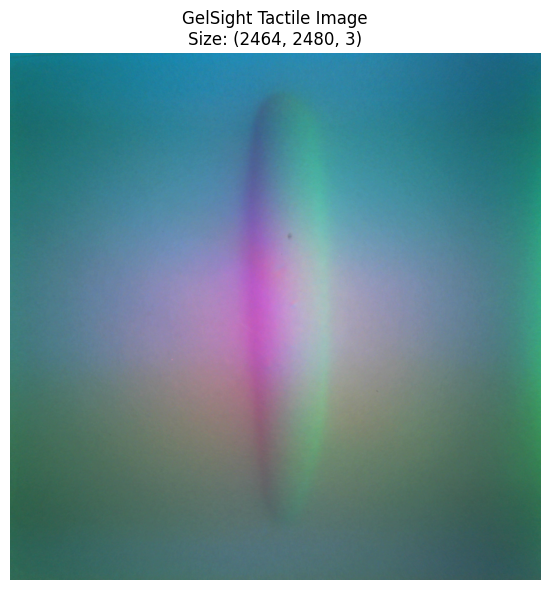

Image shape: (2464, 2480, 3)
Image dtype: uint8


In [18]:
# Load the GelSight image
# Replace with your actual image path
image_path = '/home/nuc_6g_life_3/franka_ws/src/tactile_cameras/examples/my_photo-4.jpg'  # Update this path


# For demonstration, let's create a synthetic GelSight-like image
# You can replace this with cv2.imread(image_path) for real data
def create_synthetic_cable_image(height=240, width=320):
    """Create a synthetic GelSight image with a cable impression"""
    img = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Create green background (typical GelSight)
    img[:, :, 1] = 150  # Green channel
    img[:, :, 2] = 100  # Some blue
    
    # Create cable impression (darker region with gradient)
    cable_center_y = height // 2
    cable_width = 40
    
    for y in range(height):
        dist_from_center = abs(y - cable_center_y)
        if dist_from_center < cable_width:
            # Create depth-like shading
            intensity = 1.0 - (dist_from_center / cable_width) ** 2
            img[y, :, 0] = int(50 * intensity)  # Red channel
            img[y, :, 1] = int(150 - 100 * intensity)  # Green channel
            img[y, :, 2] = int(100 - 50 * intensity)  # Blue channel
    
    # Add marker dots pattern
    for y in range(10, height-10, 20):
        for x in range(10, width-10, 20):
            cv2.circle(img, (x, y), 3, (80, 80, 80), -1)
    
    return img

# Try to load real image, otherwise use synthetic
try:
    image = cv2.imread(image_path)
    h, w, _ = image.shape
    hmargin = 0  # pixels
    wmargin = 400  # pixels
    image = image[hmargin:h-hmargin, wmargin:w-wmargin]
    if image is None:
        raise FileNotFoundError
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"Loaded real image from {image_path}")
except:
    image = create_synthetic_cable_image()
    print("Using synthetic GelSight image for demonstration")

# Display the image
plt.figure(figsize=(12, 6))
plt.imshow(image)
plt.title(f'GelSight Tactile Image\nSize: {image.shape}')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")

## 2. Compute Depth Map using Photometric Stereo

GelSight uses photometric stereo principles. We estimate surface normals from the RGB channels,
which encode lighting information from different directions.

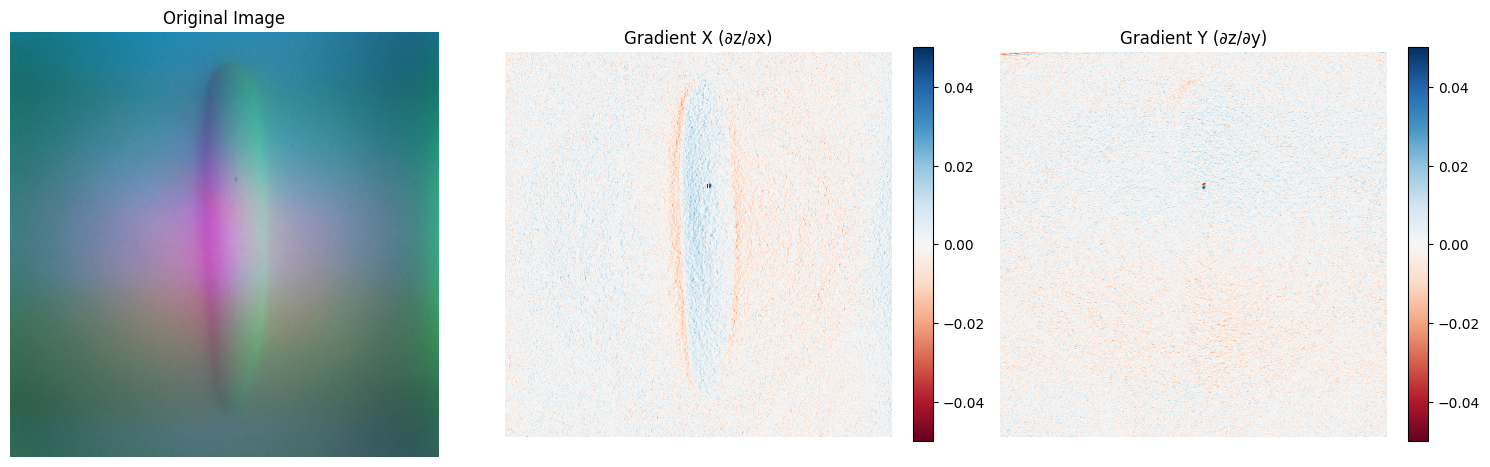

Gradient X range: [-0.140, 0.117]
Gradient Y range: [-0.093, 0.101]


In [35]:
def suppress_isolated_gradients(grad, ksize=7, sigma=0.01):
    """
    Atenua gradientes que não têm suporte local (vizinhos similares)

    Args:
        grad: mapa de gradiente (float32)
        ksize: tamanho da vizinhança
        sigma: controla quão agressiva é a supressão

    Returns:
        grad_filtered
    """
    # Média local
    local_mean = cv2.GaussianBlur(grad, (ksize, ksize), 0)

    # Diferença em relação aos vizinhos
    diff = np.abs(grad - local_mean)

    # Peso contínuo (0–1)
    weights = np.exp(-diff / sigma)

    return grad * weights


def compute_gradients_from_image(image, reference_image=None):
    """
    Compute surface gradients from GelSight image using photometric stereo principles.
    
    Args:
        image: RGB image from GelSight sensor
        reference_image: Optional reference image (no contact)
    
    Returns:
        grad_x, grad_y: Surface gradients in x and y directions
    """
    # Convert to float
    img_float = image.astype(np.float32) / 255.0
    
    # If reference image provided, compute difference
    if reference_image is not None:
        ref_float = reference_image.astype(np.float32) / 255.0
        img_float = img_float - ref_float
    
    # Extract channels
    R = img_float[:, :, 0]
    G = img_float[:, :, 1]
    B = img_float[:, :, 2]
    
    # Compute intensity-based gradients
    # In a calibrated GelSight, these would come from photometric stereo equations
    # Here we approximate using intensity differences
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    # Compute gradients using Sobel operators
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=5) / 255.0
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=5) / 255.0
    
    # Normalize gradients
    grad_x = grad_x * 0.1  # Scale factor for realistic depth
    grad_y = grad_y * 0.1
    
    return grad_x, grad_y



# Compute gradients
grad_x, grad_y = compute_gradients_from_image(image)

# Suppress isolated gradients (CONSISTÊNCIA LOCAL)
grad_x = suppress_isolated_gradients(grad_x, ksize=7, sigma=0.01)
grad_y = suppress_isolated_gradients(grad_y, ksize=7, sigma=0.01)

# Visualize gradients
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

im1 = axes[1].imshow(grad_x, cmap='RdBu', vmin=-0.05, vmax=0.05)
axes[1].set_title('Gradient X (∂z/∂x)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(grad_y, cmap='RdBu', vmin=-0.05, vmax=0.05)
axes[2].set_title('Gradient Y (∂z/∂y)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Gradient X range: [{grad_x.min():.3f}, {grad_x.max():.3f}]")
print(f"Gradient Y range: [{grad_y.min():.3f}, {grad_y.max():.3f}]")

## 3. Fast Poisson Solver for Surface Integration

We integrate the surface gradients to reconstruct the depth map using the Poisson equation:
$$\nabla^2 z = \nabla \cdot \mathbf{g}$$

where $\mathbf{g} = (g_x, g_y)$ are the gradients and $z$ is the depth.

Solving Poisson equation for depth reconstruction...


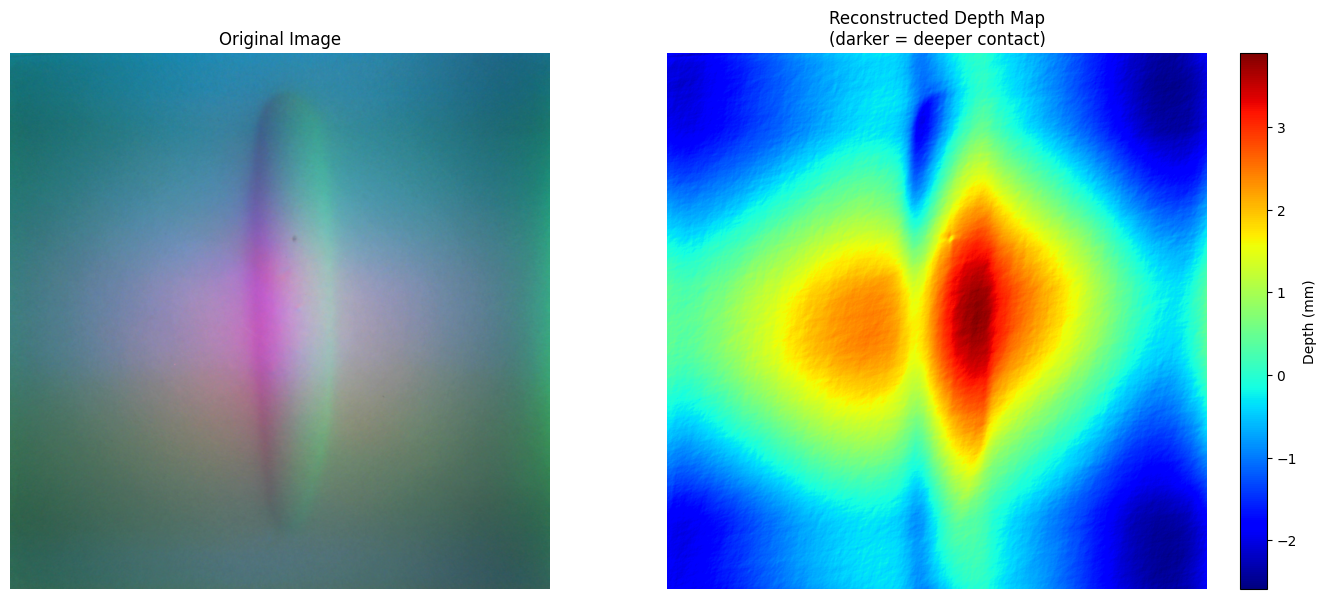

Depth range: [-2.592, 3.905]
Depth mean: -0.000
Depth std: 1.369


In [36]:
def fast_poisson_solver(grad_x, grad_y):
    """
    Solve Poisson equation to integrate gradients into depth map.
    Uses Fast Fourier Transform for efficient solution.
    
    Args:
        grad_x: Gradient in x direction
        grad_y: Gradient in y direction
    
    Returns:
        depth: Reconstructed depth map
    """
    rows, cols = grad_x.shape
    
    # Compute divergence of gradient field
    div_x = np.zeros_like(grad_x)
    div_y = np.zeros_like(grad_y)
    
    div_x[:, :-1] = grad_x[:, 1:] - grad_x[:, :-1]
    div_y[:-1, :] = grad_y[1:, :] - grad_y[:-1, :]
    
    divergence = div_x + div_y
    
    # Solve Poisson equation using FFT
    # ∇²z = divergence
    
    # Create frequency domain Laplacian operator
    cy, cx = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # Frequency domain coordinates
    fx = 2 * np.cos(np.pi * cx / rows) - 2
    fy = 2 * np.cos(np.pi * cy / cols) - 2
    
    # Laplacian in frequency domain
    laplacian_freq = fx + fy
    laplacian_freq[0, 0] = 1  # Avoid division by zero
    
    # FFT of divergence
    divergence_freq = np.fft.fft2(divergence)
    
    # Solve in frequency domain
    depth_freq = divergence_freq / laplacian_freq
    depth_freq[0, 0] = 0  # Set DC component to zero (mean depth = 0)
    
    # Inverse FFT to get depth
    depth = np.real(np.fft.ifft2(depth_freq))
    
    return depth

# Solve for depth
print("Solving Poisson equation for depth reconstruction...")
depth_map = fast_poisson_solver(grad_x, grad_y)

# Normalize depth for visualization
depth_normalized = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())

# Visualize depth map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

im = axes[1].imshow(depth_map, cmap='jet')
axes[1].set_title('Reconstructed Depth Map\n(darker = deeper contact)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, label='Depth (mm)')

plt.tight_layout()
plt.show()

print(f"Depth range: [{depth_map.min():.3f}, {depth_map.max():.3f}]")
print(f"Depth mean: {depth_map.mean():.3f}")
print(f"Depth std: {depth_map.std():.3f}")

## 4. Extract Contact Region by Thresholding

We threshold the depth map to identify the contact region where the cable is pressing into the sensor.

Depth threshold: 2.794
Number of contact regions found: 1
Contact areas: [182515.0]
Total contact area: 182515.0 pixels


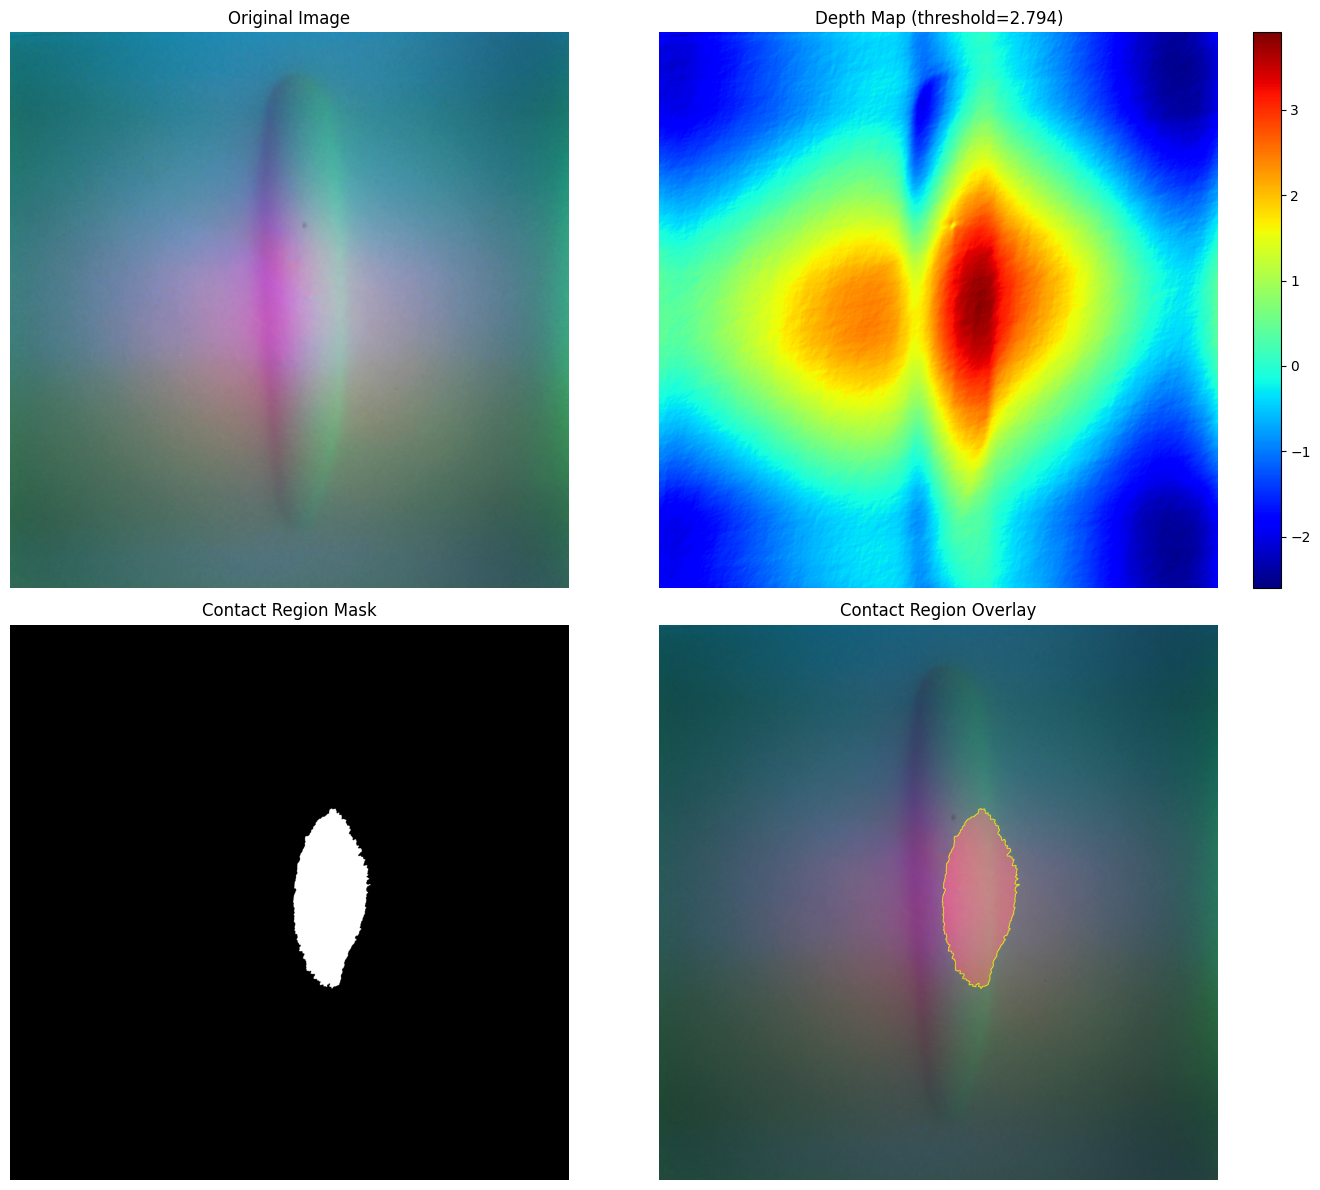

In [42]:
def extract_contact_region(depth_map, threshold_percentile=90, min_area=100):
    """
    Extract contact region from depth map using adaptive thresholding.
    
    Args:
        depth_map: Depth map from Poisson solver
        threshold_percentile: Percentile for depth threshold
        min_area: Minimum area for valid contact region
    
    Returns:
        mask: Binary mask of contact region
        contours: Contours of contact regions
    """
    # Compute threshold based on depth distribution
    threshold = np.percentile(depth_map, threshold_percentile)
    
    # Create binary mask (contact regions are typically deeper/higher depending on convention)
    # Assuming positive depth = contact (press into sensor)
    mask = (depth_map > threshold).astype(np.uint8)
    
    # Apply morphological operations to clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter by area
    valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
    
    # Create refined mask from valid contours
    refined_mask = np.zeros_like(mask)
    cv2.drawContours(refined_mask, valid_contours, -1, 1, -1)
    
    return refined_mask, valid_contours, threshold

# Extract contact region
contact_mask, contours, threshold = extract_contact_region(depth_map, threshold_percentile=97, min_area=100)

print(f"Depth threshold: {threshold:.3f}")
print(f"Number of contact regions found: {len(contours)}")
if len(contours) > 0:
    areas = [cv2.contourArea(c) for c in contours]
    print(f"Contact areas: {areas}")
    print(f"Total contact area: {sum(areas):.1f} pixels")

# Visualize contact extraction
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Original image
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Depth map with threshold line
im1 = axes[0, 1].imshow(depth_map, cmap='jet')
axes[0, 1].set_title(f'Depth Map (threshold={threshold:.3f})')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Contact mask
axes[1, 0].imshow(contact_mask, cmap='gray')
axes[1, 0].set_title('Contact Region Mask')
axes[1, 0].axis('off')

# Overlay on original
overlay = image.copy()
# Create colored mask overlay
mask_colored = np.zeros_like(image)
mask_colored[:, :, 0] = contact_mask * 255  # Red channel
overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)
# Draw contours
for contour in contours:
    cv2.drawContours(overlay, [contour], -1, (255, 255, 0), 2)
axes[1, 1].imshow(overlay)
axes[1, 1].set_title('Contact Region Overlay')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 5. Estimate Cable Pose

From the contact region, we estimate the cable's:
- **Center position** (x, y)
- **Orientation angle** θ
- **Width** (perpendicular to cable axis)

We use PCA (Principal Component Analysis) to find the main axis of the cable.

In [43]:
def estimate_cable_pose(contact_mask, depth_map):
    """
    Estimate cable pose from contact region.
    
    Args:
        contact_mask: Binary mask of contact region
        depth_map: Depth map
    
    Returns:
        pose: Dictionary containing center, angle, width, length
    """
    # Get contact points
    contact_points = np.column_stack(np.where(contact_mask > 0))
    
    if len(contact_points) < 10:
        return None
    
    # Compute center (centroid)
    center_y = np.mean(contact_points[:, 0])
    center_x = np.mean(contact_points[:, 1])
    
    # Use PCA to find principal axis (cable orientation)
    # Convert to (x, y) format for PCA
    points_xy = contact_points[:, [1, 0]]  # Swap to (x, y)
    
    pca = PCA(n_components=2)
    pca.fit(points_xy)
    
    # First principal component is the cable direction
    direction = pca.components_[0]
    angle = np.arctan2(direction[1], direction[0])
    angle_deg = np.degrees(angle)
    
    # Estimate cable dimensions
    # Project points onto principal axes
    projected = pca.transform(points_xy)
    
    # Length along main axis, width along perpendicular axis
    length = np.ptp(projected[:, 0])  # Peak-to-peak along first PC
    width = np.ptp(projected[:, 1])   # Peak-to-peak along second PC
    
    # Compute average depth in contact region
    contact_depths = depth_map[contact_mask > 0]
    avg_depth = np.mean(contact_depths)
    max_depth = np.max(contact_depths)
    
    pose = {
        'center': (center_x, center_y),
        'angle_rad': angle,
        'angle_deg': angle_deg,
        'length': length,
        'width': width,
        'avg_depth': avg_depth,
        'max_depth': max_depth,
        'num_points': len(contact_points),
        'pca': pca
    }
    
    return pose

# Estimate cable pose
cable_pose = estimate_cable_pose(contact_mask, depth_map)

if cable_pose is not None:
    print("\n=== Cable Pose Estimation ===")
    print(f"Center position: ({cable_pose['center'][0]:.1f}, {cable_pose['center'][1]:.1f}) pixels")
    print(f"Orientation angle: {cable_pose['angle_deg']:.1f}°")
    print(f"Cable length: {cable_pose['length']:.1f} pixels")
    print(f"Cable width: {cable_pose['width']:.1f} pixels")
    print(f"Average contact depth: {cable_pose['avg_depth']:.3f}")
    print(f"Maximum contact depth: {cable_pose['max_depth']:.3f}")
    print(f"Number of contact points: {cable_pose['num_points']}")
    print(f"\nExplained variance ratio: {cable_pose['pca'].explained_variance_ratio_}")
else:
    print("Could not estimate cable pose - insufficient contact points")


=== Cable Pose Estimation ===
Center position: (1416.7, 1212.5) pixels
Orientation angle: 93.0°
Cable length: 795.0 pixels
Cable width: 337.7 pixels
Average contact depth: 3.273
Maximum contact depth: 3.905
Number of contact points: 183575

Explained variance ratio: [0.85191038 0.14808962]


## 6. Visualize Cable Pose Estimation

Final visualization showing the estimated cable pose overlaid on the original image.

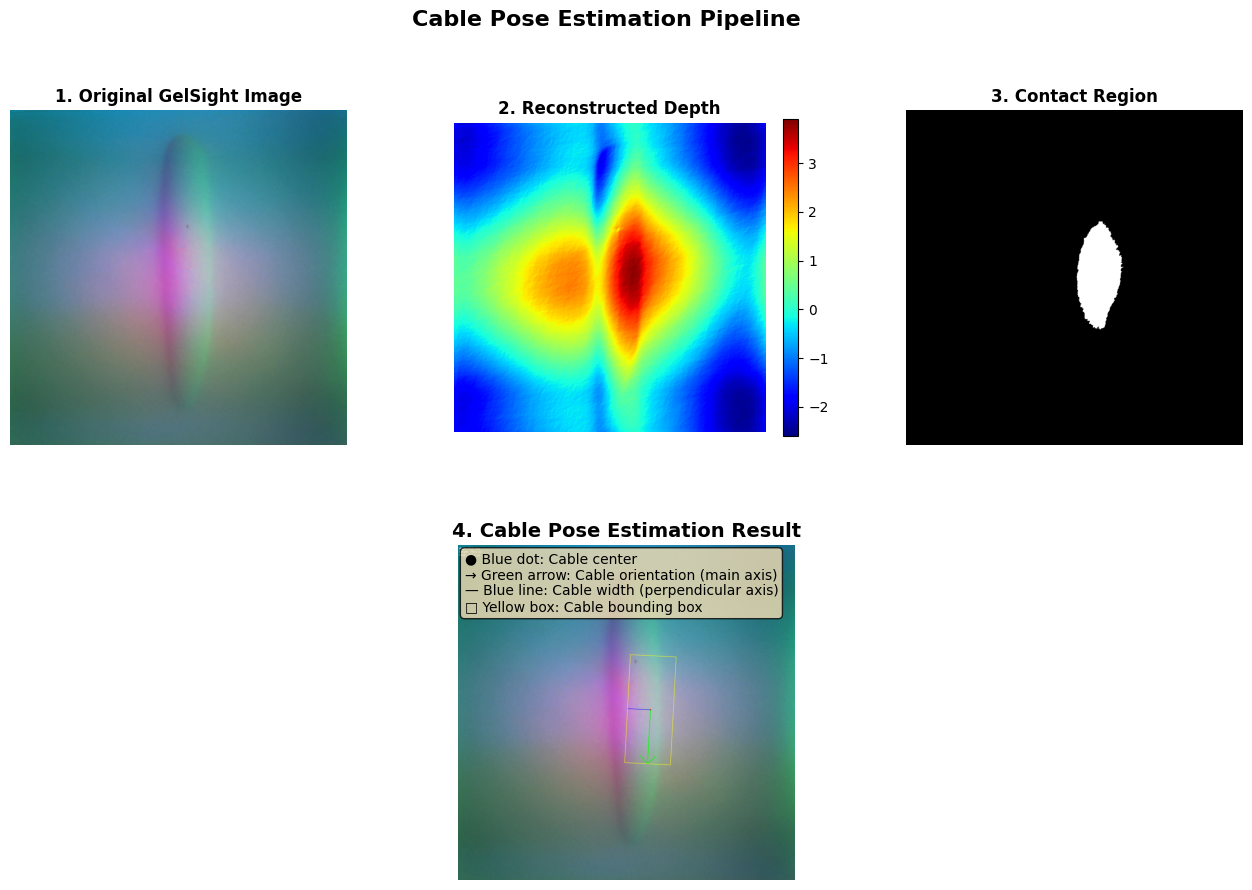


CABLE POSE ESTIMATION SUMMARY
Position (pixels):    (1416.7, 1212.5)
Orientation (degrees): 93.0°
Length (pixels):       795.0
Width (pixels):        337.7
Aspect ratio:          2.35:1
Max depth:             3.905
Contact area:          183575 pixels


In [44]:
def draw_cable_pose(image, pose, scale=50):
    """
    Draw estimated cable pose on image.
    
    Args:
        image: Original image
        pose: Pose dictionary from estimate_cable_pose
        scale: Scale factor for drawing vectors
    
    Returns:
        annotated_image: Image with pose visualization
    """
    annotated = image.copy()
    
    if pose is None:
        return annotated
    
    center = tuple(map(int, pose['center']))
    angle = pose['angle_rad']
    length = pose['length']
    width = pose['width']
    
    # Draw center point
    cv2.circle(annotated, center, 5, (255, 0, 0), -1)
    
    # Draw main axis (cable orientation)
    axis_length = int(length / 2)
    end_x = int(center[0] + axis_length * np.cos(angle))
    end_y = int(center[1] + axis_length * np.sin(angle))
    cv2.arrowedLine(annotated, center, (end_x, end_y), (0, 255, 0), 3, tipLength=0.2)
    
    # Draw perpendicular axis (cable width)
    perp_angle = angle + np.pi/2
    perp_length = int(width / 2)
    perp_x = int(center[0] + perp_length * np.cos(perp_angle))
    perp_y = int(center[1] + perp_length * np.sin(perp_angle))
    cv2.line(annotated, center, (perp_x, perp_y), (0, 0, 255), 2)
    
    # Draw bounding box around cable
    # Corners of rotated rectangle
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    half_length, half_width = length/2, width/2
    
    corners = []
    for l_sign, w_sign in [(-1, -1), (1, -1), (1, 1), (-1, 1)]:
        x = center[0] + l_sign * half_length * cos_a - w_sign * half_width * sin_a
        y = center[1] + l_sign * half_length * sin_a + w_sign * half_width * cos_a
        corners.append((int(x), int(y)))
    
    # Draw rectangle
    for i in range(4):
        cv2.line(annotated, corners[i], corners[(i+1)%4], (255, 255, 0), 2)
    
    # Add text annotation
    text_y = 30
    cv2.putText(annotated, f"Angle: {pose['angle_deg']:.1f} deg", (10, text_y), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    cv2.putText(annotated, f"Length: {pose['length']:.1f} px", (10, text_y + 25), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    cv2.putText(annotated, f"Width: {pose['width']:.1f} px", (10, text_y + 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return annotated

# Create visualization
if cable_pose is not None:
    result_image = draw_cable_pose(image, cable_pose)
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Original image
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(image)
    ax1.set_title('1. Original GelSight Image', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Depth map
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(depth_map, cmap='jet')
    ax2.set_title('2. Reconstructed Depth', fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046)
    
    # Contact mask
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(contact_mask, cmap='gray')
    ax3.set_title('3. Contact Region', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    # Final result
    ax4 = fig.add_subplot(gs[1, :])
    ax4.imshow(result_image)
    ax4.set_title('4. Cable Pose Estimation Result', fontsize=14, fontweight='bold')
    ax4.axis('off')
    
    # Add legend
    legend_text = [
        "● Blue dot: Cable center",
        "→ Green arrow: Cable orientation (main axis)",
        "— Blue line: Cable width (perpendicular axis)",
        "□ Yellow box: Cable bounding box"
    ]
    legend_str = "\n".join(legend_text)
    ax4.text(0.02, 0.98, legend_str, transform=ax4.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.suptitle('Cable Pose Estimation Pipeline', fontsize=16, fontweight='bold', y=0.98)
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("CABLE POSE ESTIMATION SUMMARY")
    print("="*60)
    print(f"Position (pixels):    ({cable_pose['center'][0]:.1f}, {cable_pose['center'][1]:.1f})")
    print(f"Orientation (degrees): {cable_pose['angle_deg']:.1f}°")
    print(f"Length (pixels):       {cable_pose['length']:.1f}")
    print(f"Width (pixels):        {cable_pose['width']:.1f}")
    print(f"Aspect ratio:          {cable_pose['length']/cable_pose['width']:.2f}:1")
    print(f"Max depth:             {cable_pose['max_depth']:.3f}")
    print(f"Contact area:          {cable_pose['num_points']} pixels")
    print("="*60)
else:
    print("Cannot visualize - no cable pose estimated")

## 7. Convert to Physical Units (Optional)

If calibrated, convert pixel measurements to real-world units (mm).

In [ ]:
# GelSight calibration parameters (example values)
# These should be obtained from camera calibration
PIXEL_TO_MM = 0.03  # mm per pixel (example)
DEPTH_SCALE = 0.5   # Scale factor for depth (example)

def convert_to_physical_units(pose, pixel_to_mm=PIXEL_TO_MM, depth_scale=DEPTH_SCALE):
    """
    Convert pixel-based measurements to physical units.
    
    Args:
        pose: Pose dictionary from estimate_cable_pose
        pixel_to_mm: Conversion factor from pixels to millimeters
        depth_scale: Scale factor for depth measurements
    
    Returns:
        physical_pose: Pose in physical units
    """
    if pose is None:
        return None
    
    physical_pose = {
        'center_mm': (pose['center'][0] * pixel_to_mm, pose['center'][1] * pixel_to_mm),
        'angle_deg': pose['angle_deg'],
        'length_mm': pose['length'] * pixel_to_mm,
        'width_mm': pose['width'] * pixel_to_mm,
        'max_depth_mm': pose['max_depth'] * depth_scale,
        'avg_depth_mm': pose['avg_depth'] * depth_scale,
        'contact_area_mm2': pose['num_points'] * (pixel_to_mm ** 2)
    }
    
    return physical_pose

if cable_pose is not None:
    physical_pose = convert_to_physical_units(cable_pose)
    
    print("\n" + "="*60)
    print("CABLE POSE IN PHYSICAL UNITS")
    print("="*60)
    print(f"Center position:  ({physical_pose['center_mm'][0]:.2f}, {physical_pose['center_mm'][1]:.2f}) mm")
    print(f"Orientation:      {physical_pose['angle_deg']:.1f}°")
    print(f"Cable length:     {physical_pose['length_mm']:.2f} mm")
    print(f"Cable width:      {physical_pose['width_mm']:.2f} mm")
    print(f"Cable diameter:   ~{physical_pose['width_mm']:.2f} mm")
    print(f"Max indentation:  {physical_pose['max_depth_mm']:.3f} mm")
    print(f"Avg indentation:  {physical_pose['avg_depth_mm']:.3f} mm")
    print(f"Contact area:     {physical_pose['contact_area_mm2']:.2f} mm²")
    print("="*60)
    print("\nNote: Physical measurements require proper sensor calibration.")
    print("The values above use example calibration parameters.")

## Summary

This notebook demonstrated the complete cable pose estimation pipeline:

1. **Image Acquisition**: Load GelSight tactile sensor image
2. **Gradient Estimation**: Compute surface gradients using photometric stereo principles
3. **Depth Reconstruction**: Use Fast Poisson solver to integrate gradients into depth map
4. **Contact Extraction**: Threshold depth map to identify contact regions
5. **Pose Estimation**: Use PCA to estimate cable center, orientation, and dimensions
6. **Visualization**: Display all intermediate results and final pose estimate

### Key References

- **Paper**: "Cable Manipulation with a Tactile-Reactive Gripper" (Kaess et al., 2019)
  - arXiv: https://arxiv.org/pdf/1910.02860
- **GelSight**: MIT tactile sensor technology
- **Fast Poisson Solver**: Efficient surface reconstruction from gradients

### Next Steps

- Integrate with ROS for real-time processing
- Add cable tracking over time
- Implement force estimation from contact area and depth
- Add cable shape estimation (curved cables)
- Implement multi-cable detection and tracking